In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pygraphviz import AGraph

In [2]:
methods = [
    {
        'name': 'vgg',
        'model': 'VGG16',
    },
    # {
    #     'name': 'resnet',
    #     'model': 'ResNet18',
    # },
    {
        'name': 'resnet_ultra',
        'model': 'ResNet50',
    },
    # {
    #     'name': 'resnet_sigmoid',
    #     'model': 'ResNet18 (Sigmoid)',
    # },
    {
        'name': 'vqa',
        'model': 'VQA',
    },
    {
        'name': 'svm',
        'model': 'SVM',
    },
    {
        'name': 'log_reg',
        'model': 'Logistic Regression',
    },
]

dfs = []

for method in methods:
    # Load the predictions
    preds = pd.read_csv(f'preds_{method["name"]}.csv')
    preds = preds.rename(columns={'has_cactus': f'{method["name"]}_preds'})
    preds = preds.set_index('id')

    dfs.append(preds)

# Join the predictions
joined: pd.DataFrame = dfs.pop()
for df in dfs:
    joined = joined.join(df)

joined

,log_reg_preds,vgg_preds,resnet_ultra_preds,vqa_preds,svm_preds
id,,,,,
2046a83b3760832a7c36a3b49dc46def.jpg,0,1,1,1,1
bf98e9f9970accfe6fd983fbab270207.jpg,0,0,0,1,0
49e61bfbba2d450c5c5d16c61b0fcc4e.jpg,0,1,1,1,1
968e4f26722d9be94c7154ecfb166fcd.jpg,0,0,0,1,0
610ba78cb17346aaf162349be21e0a79.jpg,0,1,1,1,1
...,...,...,...,...,...
fb9c9c66bf3576711f1d4688feb83f5f.jpg,0,0,0,1,0
c1fb6db58fbf31a53f1c7e393024e8b2.jpg,0,0,0,0,0
c4576f56020a0c4e99ecdac611eb9cc7.jpg,1,1,1,0,1


In [3]:
G = nx.Graph()

for i, method in enumerate(methods):
    for cmethod in methods[i + 1:]:
        equals = (joined[f'{method["name"]}_preds'] == joined[f'{cmethod["name"]}_preds']).sum()
        total = len(joined)
        agree = equals / total
        print(f'{method["model"]} and {cmethod["model"]} agree on {equals} out of {total} test images. ({agree:.2%})')

        G.add_edge(method['model'], cmethod['model'], weight=agree, wperc=f"{agree:.2%}")

VGG16 and ResNet50 agree on 3870 out of 4000 test images. (96.75%)
VGG16 and VQA agree on 2261 out of 4000 test images. (56.53%)
VGG16 and SVM agree on 2987 out of 4000 test images. (74.67%)
VGG16 and Logistic Regression agree on 2380 out of 4000 test images. (59.50%)
ResNet50 and VQA agree on 2261 out of 4000 test images. (56.53%)
ResNet50 and SVM agree on 2995 out of 4000 test images. (74.88%)
ResNet50 and Logistic Regression agree on 2386 out of 4000 test images. (59.65%)
VQA and SVM agree on 1910 out of 4000 test images. (47.75%)
VQA and Logistic Regression agree on 1623 out of 4000 test images. (40.58%)
SVM and Logistic Regression agree on 2925 out of 4000 test images. (73.12%)


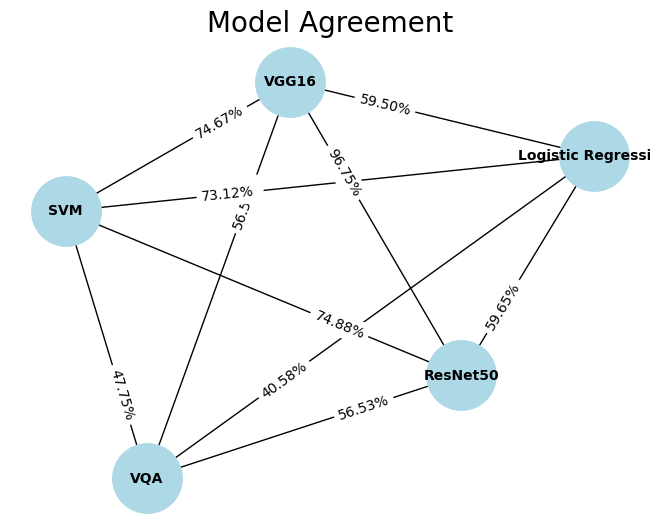

In [6]:
labels = nx.get_edge_attributes(G, 'wperc')
pos = nx.spring_layout(G, seed=42)  # positions for all nodes
# pos['SVM'] = (-0.5, -0.5)
# pos['VGG16'] = (0.55, 0.5)
nx.draw(G, pos=pos, with_labels=True, node_size=2500, node_color='lightblue', font_size=10, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=labels, label_pos=0.3)
plt.title('Model Agreement', fontsize=20)
plt.show()

In [5]:
pos

{'VGG16': (0.55, 0.5),
 'ResNet50': array([ 0.50358059, -0.52698624]),
 'VQA': array([-0.55463145, -1.        ]),
 'SVM': (-0.5, -0.5),
 'Logistic Regression': array([0.95143117, 0.48035553])}